In [31]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x = np.array( [1,2,3,4,5], np.float32)
y = np.array( [3,5,7,9,11], np.float32)

In [ ]:
class MyDense:
    def __init__(self, units=1, input_dim=1):
        self.w = np.random.uniform([input_dim])
        self.b = np.random.uniform([units])
    def __call__(self, xd):
        hx = self.w*xd + self.b
        return hx
    def get_weights(self):
        return self.w, self.b
mydense = MyDense( units=1, input_dim=1)
print( mydense( x.reshape(-1,1)) ) #mydense.__call__(x.reshape(-1,1))
print( mydense.get_weights() )

[[2.]
 [3.]
 [4.]
 [5.]
 [6.]]
(array([1.]), array([1.]))


In [ ]:
#forward 연산 정의, w, b정의되있다
#units:라벨의 갯수
#input_dim: 특성데이터 갯수
dense = Dense( units=1, input_dim=1)  
dense( x.reshape(-1,1) ) # forward hx = matmul(x,w) +b  , hx = w*x + b

c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[1.1751674],
       [2.350335 ],
       [3.5255022],
       [4.70067  ],
       [5.8758373]], dtype=float32)>

In [4]:
w, b= dense.get_weights()
print( w )
print( b )

[[1.1751674]]
[0.]


In [8]:
dense = Dense( units=1, input_dim=1)
model = Sequential( [dense]) # dense의  w와 b가 학습대상이다
model.compile( loss='mse', optimizer= Adam(0.1) )
model.fit( x, y, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - loss: 60.8725
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 54.4393
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 48.3770
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 42.6912
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 37.3865
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 32.4656
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 27.9298
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 23.7784
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 20.0087
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 16.6158
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 13.5923
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 10.9284
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 8.6118
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 6.6275
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.9579
Epoch 16/500
1/1 ━

In [9]:
w, b= dense.get_weights()
print( w )
print( b )

[[1.999767]]
[1.0008155]


In [10]:
dense( x.reshape(-1,1) )

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[ 3.0005825],
       [ 5.0003495],
       [ 7.0001163],
       [ 8.999884 ],
       [10.99965  ]], dtype=float32)>

In [ ]:
model.predict( x ) # 값을 전처리( 행렬변환), dense의 forward 호출

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[ 3.0005825],
       [ 5.0003495],
       [ 7.0001163],
       [ 8.999884 ],
       [10.99965  ]], dtype=float32)

### 10분 퀴즈 
cars.csv 케라스로 학습 자동차속도 20인 경우 제동거리 예측하시

In [13]:
df = pd.read_csv('data/cars.csv', index_col='Unnamed: 0')
df

,speed,dist
1,4,2
2,4,10
3,7,4
4,7,22
5,8,16
6,9,10
7,10,18
8,10,26
9,10,34
10,11,17


In [14]:
x = df['speed'].values
y = df['dist'].values

In [27]:
dense = Dense( units=1, input_dim=1)
model = Sequential( [dense]) # dense의  w와 b가 학습대상이다
model.compile( loss='mse', optimizer= Adam(0.1) )
h = model.fit( x, y, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1969.8278 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1697.4603
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1450.0492
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1224.3228
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1025.9619
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 855.1772
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 723.1489
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 598.7297
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 498.0371
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 425.8421
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 365.9383
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 321.6669
Epoch 13/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 297.4009
Epoch 14/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 279.3347
Epoch 15/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 270.

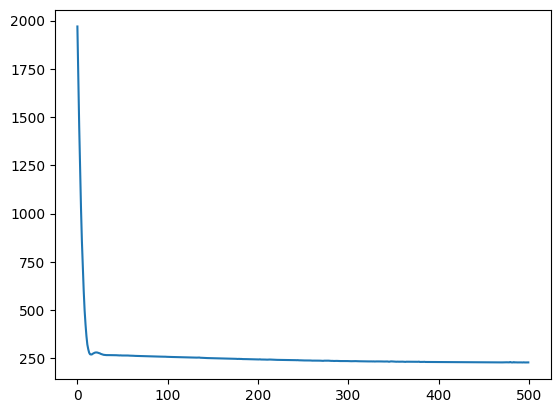

In [32]:
h.history['loss']
plt.plot(h.history['loss'] )

In [20]:
model.predict( np.array([20]) )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


array([[59.5255]], dtype=float32)

In [21]:
w, b = dense.get_weights()
print( w)
print( b )

[[3.503209]]
[-10.538676]


In [22]:
20*w + b 

array([[59.5255]], dtype=float32)

In [24]:
y_pred = model.predict(x)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


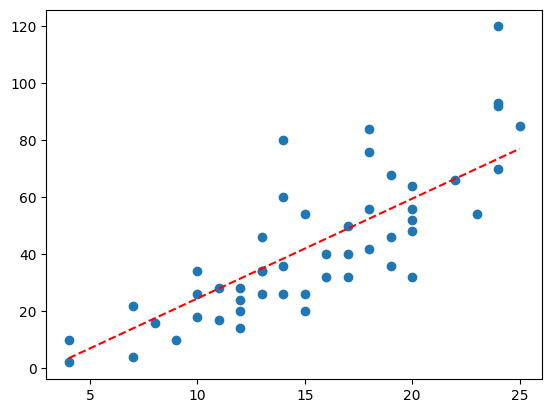

In [26]:
import matplotlib.pyplot as plt

plt.scatter(x,y)
plt.plot( x, y_pred, 'r--')
plt.show()